In [21]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns

# Custom modules
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
from spk_feat_cluster_comp_analysis  import *

In [22]:
cluster_pickle_dir = "/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spe1_pickles/cluster_pickles/"

### Step 1: Create dataframe with all experiment metadata and clustering results

In [23]:
#create df for all experiments 
df_master = compile_experiment_results(cluster_pickle_dir)


In [24]:
df_master

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
0,c1,Juxta,IC,PC,843.9,False,False,peak_amp,3,Low-High,0.097334,0.990675,-0.836876,1.362049e-294,1.0
1,c1,Juxta,IC,PC,843.9,False,False,peak_sharpness,3,Low-High,0.089531,0.994335,-0.696692,2.509393e-163,1.0
2,c1,Juxta,IC,PC,843.9,False,False,exp_lambda,3,Low-High,0.057151,0.991093,-0.513388,2.884357e-76,1.0
3,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-Mid,0.042822,0.998956,0.349626,1.720911e-33,1.0
4,c1,Juxta,IC,PC,843.9,False,False,log_isi,3,Low-High,0.039851,0.999172,0.349626,1.720911e-33,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098067,0.906951,0.438847,1.952396e-289,1.0
124,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-High,0.057792,0.970615,0.438847,1.952396e-289,1.0
125,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Mid-High,0.043976,0.980540,0.438847,1.952396e-289,1.0
126,c46,Juxta,VC,PC,1039.7,False,True,exp_lambda,2,Low-High,0.008711,0.999816,-0.045723,3.193497e-04,1.0


In [25]:
#sort by cell id
# Create a numeric column for sorting (c1, c2, c10, etc.)
df_master['sort_idx'] = df_master['cell_id'].str.extract('(\d+)').astype(int)

# Sort by the numeric ID, then by feature name
df_master = df_master.sort_values(by=['sort_idx', 'spike_feature']).drop(columns=['sort_idx'])



### Step 2: Generate table figure from dataframe 


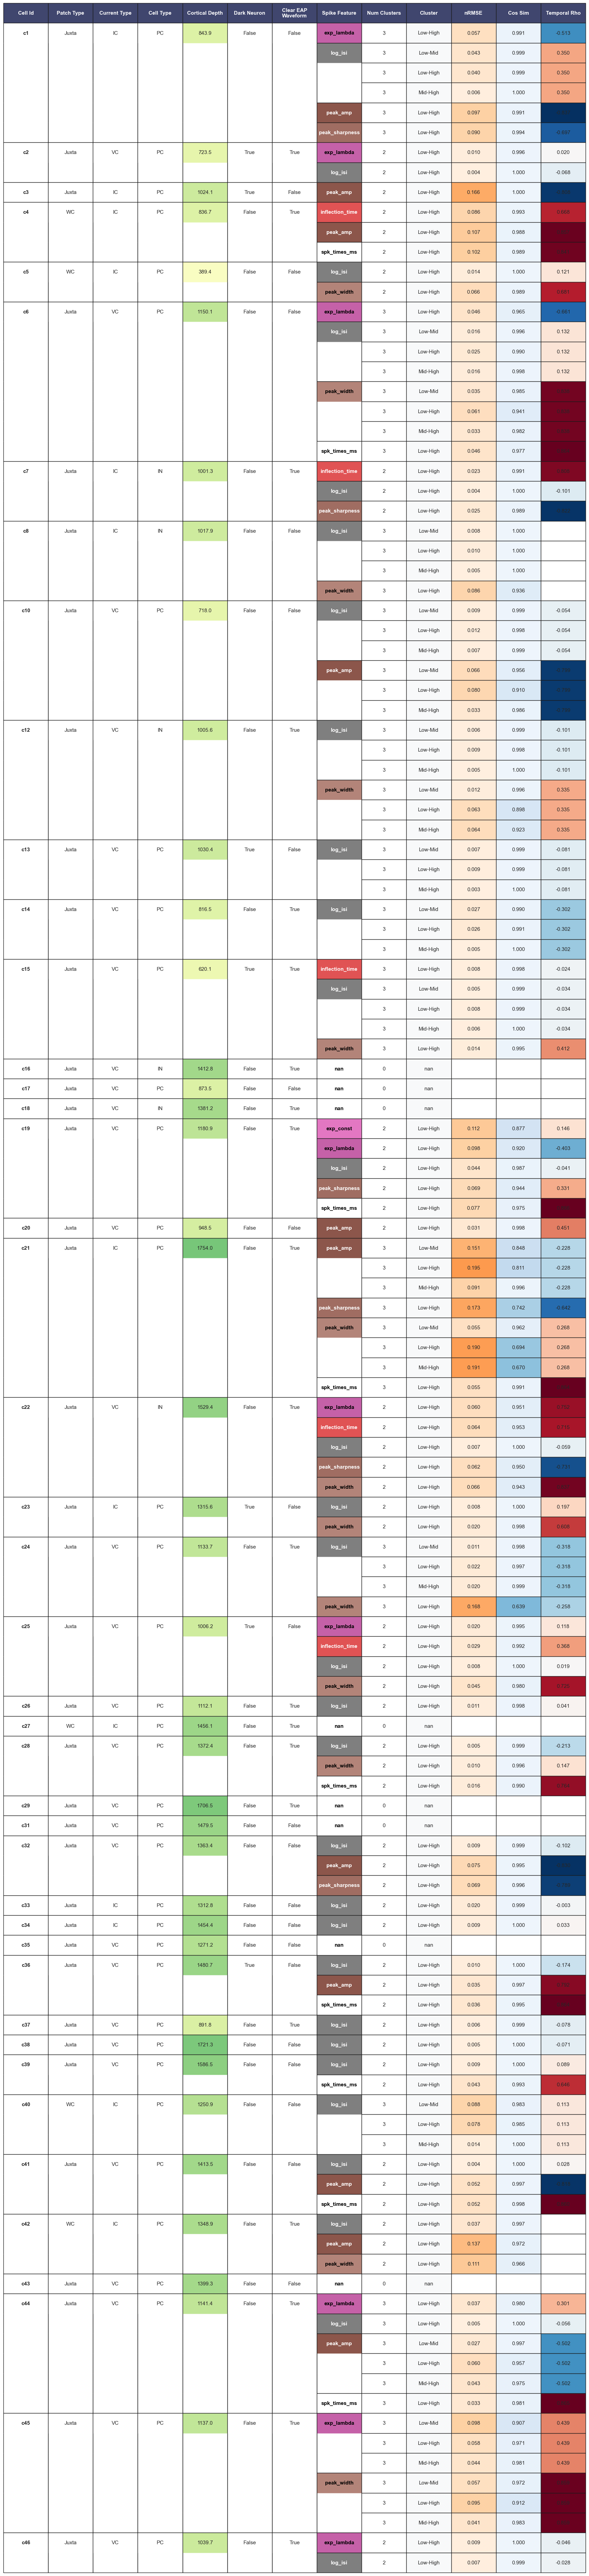

In [26]:

gen_table_fig(df_master)


### Step 3: Patterns for clustering/metadata

#### A) Do metadata features correlate with clustering waveform quantification (nRMSE, cos sim, number of clusters)

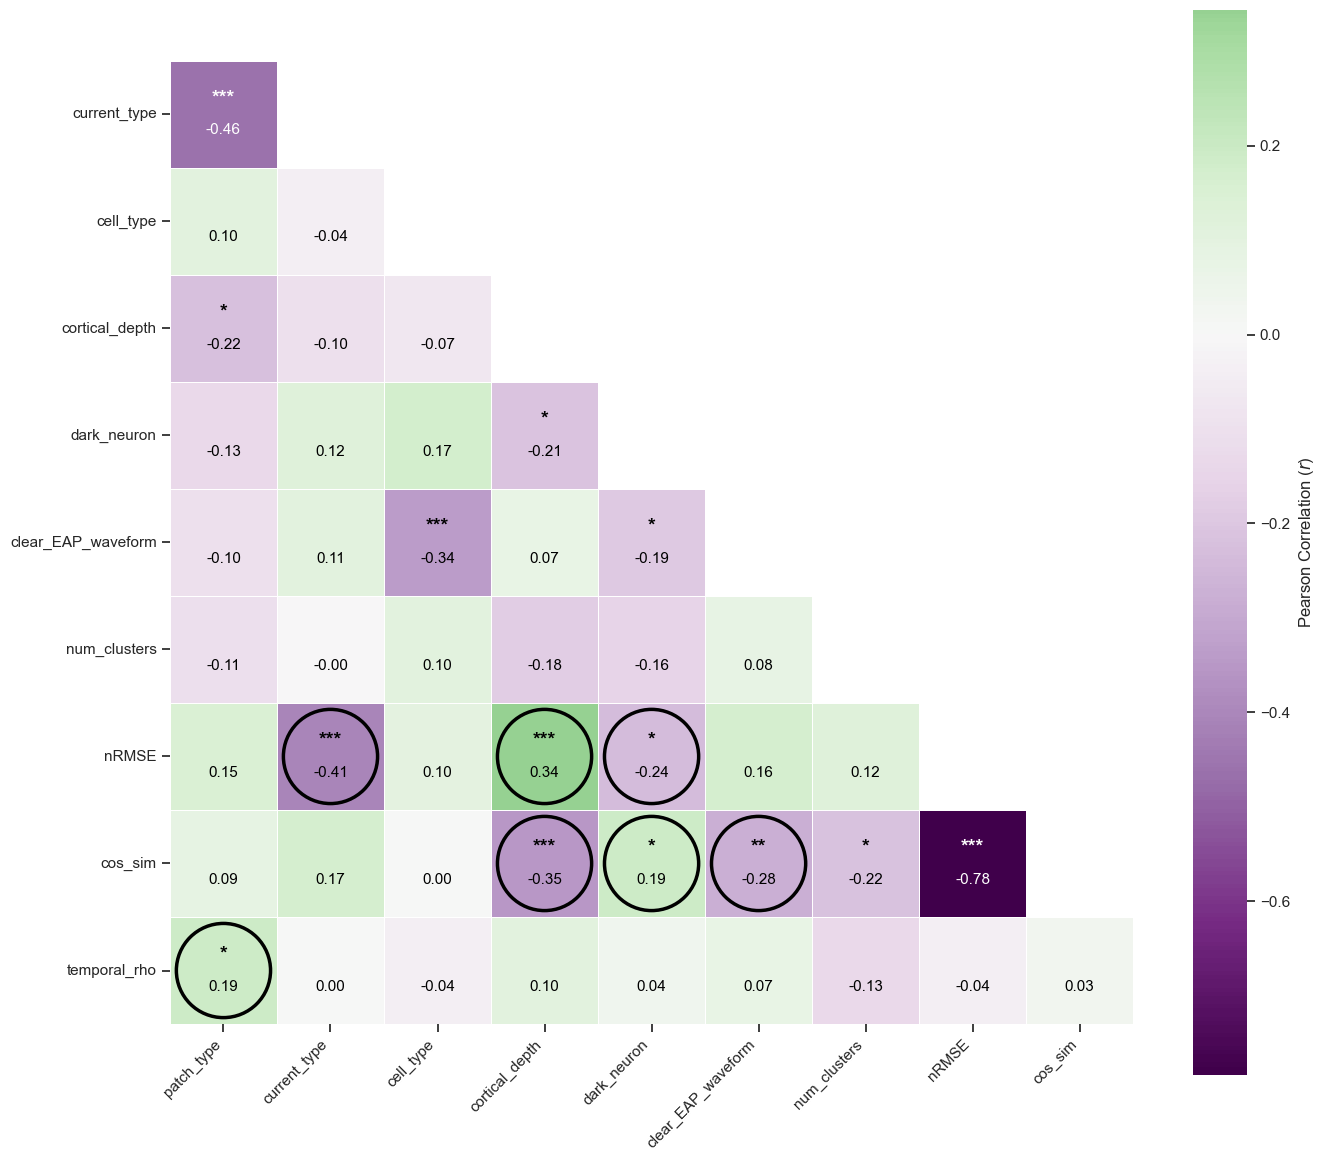

,Metadata,Feature,Pearson $r$,p-value,Significance
0,current_type,nRMSE,-0.407,7.58e-06,***
1,cortical_depth,cos_sim,-0.352,1.29e-04,***
2,cortical_depth,nRMSE,0.344,1.91e-04,***
3,clear_EAP_waveform,cos_sim,-0.279,2.81e-03,**
4,dark_neuron,nRMSE,-0.236,1.19e-02,*
5,patch_type,temporal_rho,0.193,4.06e-02,*
6,dark_neuron,cos_sim,0.190,4.35e-02,*


In [27]:
sig_meta_clust_feats = analyze_cross_correlations(df_master)
sig_meta_clust_feats

#### Explore the pairs that are correlated

In [ ]:
plot_sig_feat_pairs(df_master, sig_meta_clust_feats)



#### B) Study patterns in the spike features that cluster

##### Analyze spike features and cluster features

In [ ]:
#Aggregate cluster metrics and prevalence by spike feature
spk_feat_prevalence = quantify_spk_feature_prevalence(df_master)


In [ ]:
spk_feat_prevalence

,spike_feature,n_cells_with_feature,prevalence_pct,num_clusters,cos_sim,nRMSE,temporal_rho
3,log_isi,30,69.767442,2.620000,0.997801,0.015414,-0.009295
6,peak_width,13,30.232558,2.714286,0.921870,0.070711,0.515493
4,peak_amp,11,25.581395,2.588235,0.963162,0.085143,-0.361274
1,exp_lambda,9,20.930233,2.545455,0.968775,0.048846,-0.054005
7,spk_times_ms,9,20.930233,2.333333,0.987679,0.051211,0.825800
5,peak_sharpness,6,13.953488,2.333333,0.935959,0.081216,-0.558334
2,inflection_time,5,11.627907,2.200000,0.985302,0.042013,0.507107
0,exp_const,1,2.325581,2.000000,0.876527,0.112284,0.145825


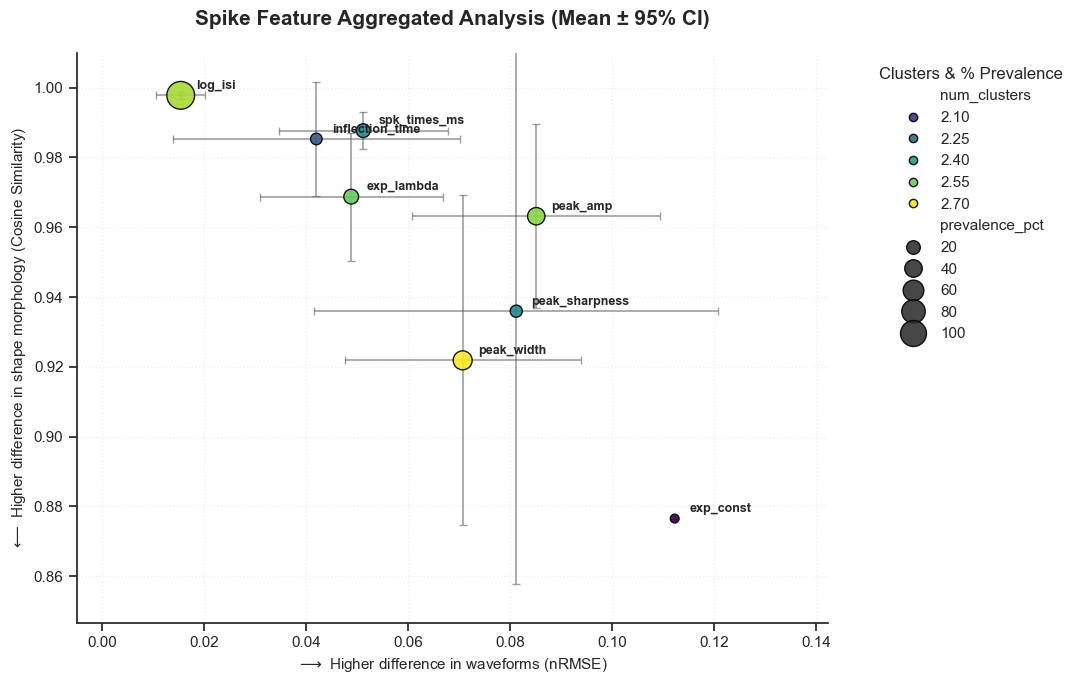

In [ ]:
plot_aggregated_spike_feat(df_master)


##### Analyze spike features in relation to metadata

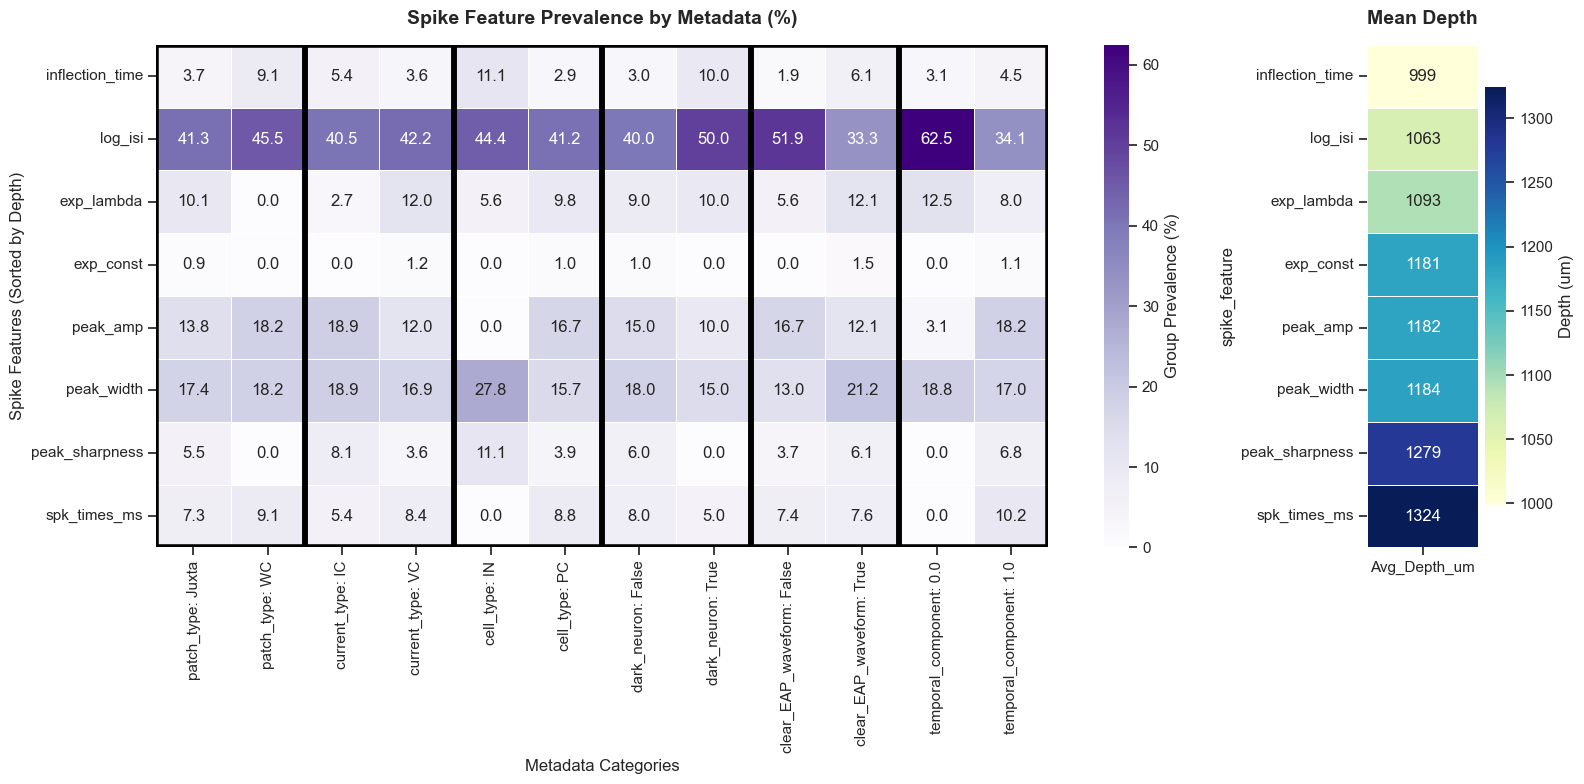

In [ ]:
plot_meta_spk_feature_dependency(df_master)

In [ ]:

_ = stat_test_metadata_dependency(df_master)

----------------------------------------
METADATA DEPENDENCY ANALYSIS (Chi-Square)
----------------------------------------
patch_type           | p = 9.076e-01 (ns)
current_type         | p = 6.163e-01 (ns)
cell_type            | p = 1.662e-01 (ns)
dark_neuron          | p = 7.377e-01 (ns)
clear_EAP_waveform   | p = 3.468e-01 (ns)
temporal_rho         | p = 7.938e-09 (***)
temporal_p           | p = 7.988e-06 (***)
temporal_component   | p = 3.864e-02 (*)
----------------------------------------


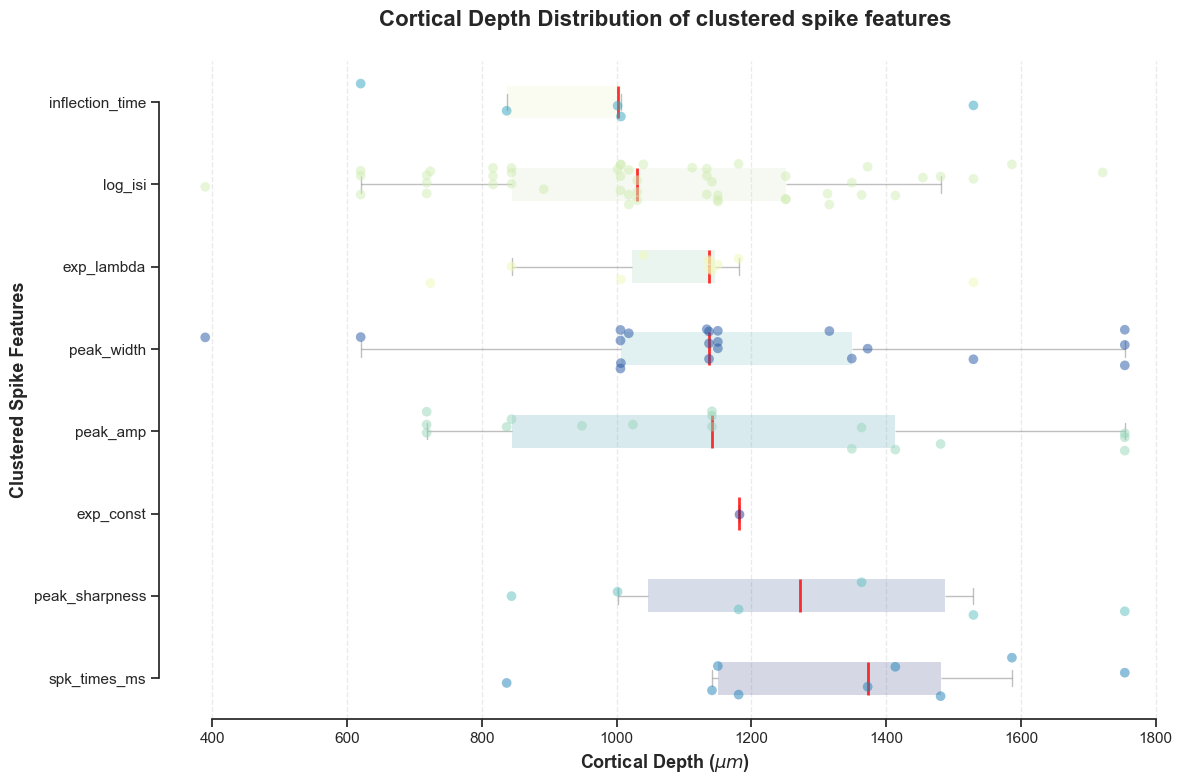

In [ ]:
plot_feature_depth_distribution(df_master)

In [ ]:
_ =stat_test_depth_stratification(df_master)

----------------------------------------
DEPTH STRATIFICATION ANALYSIS
----------------------------------------
Kruskal-Wallis H-stat: 10.583
p-value: 1.579e-01

No significant depth stratification found.
----------------------------------------


#### C) What are the experiments with the biggest difference in waveform (nRMSE) and waveform abs shape (cos sim)

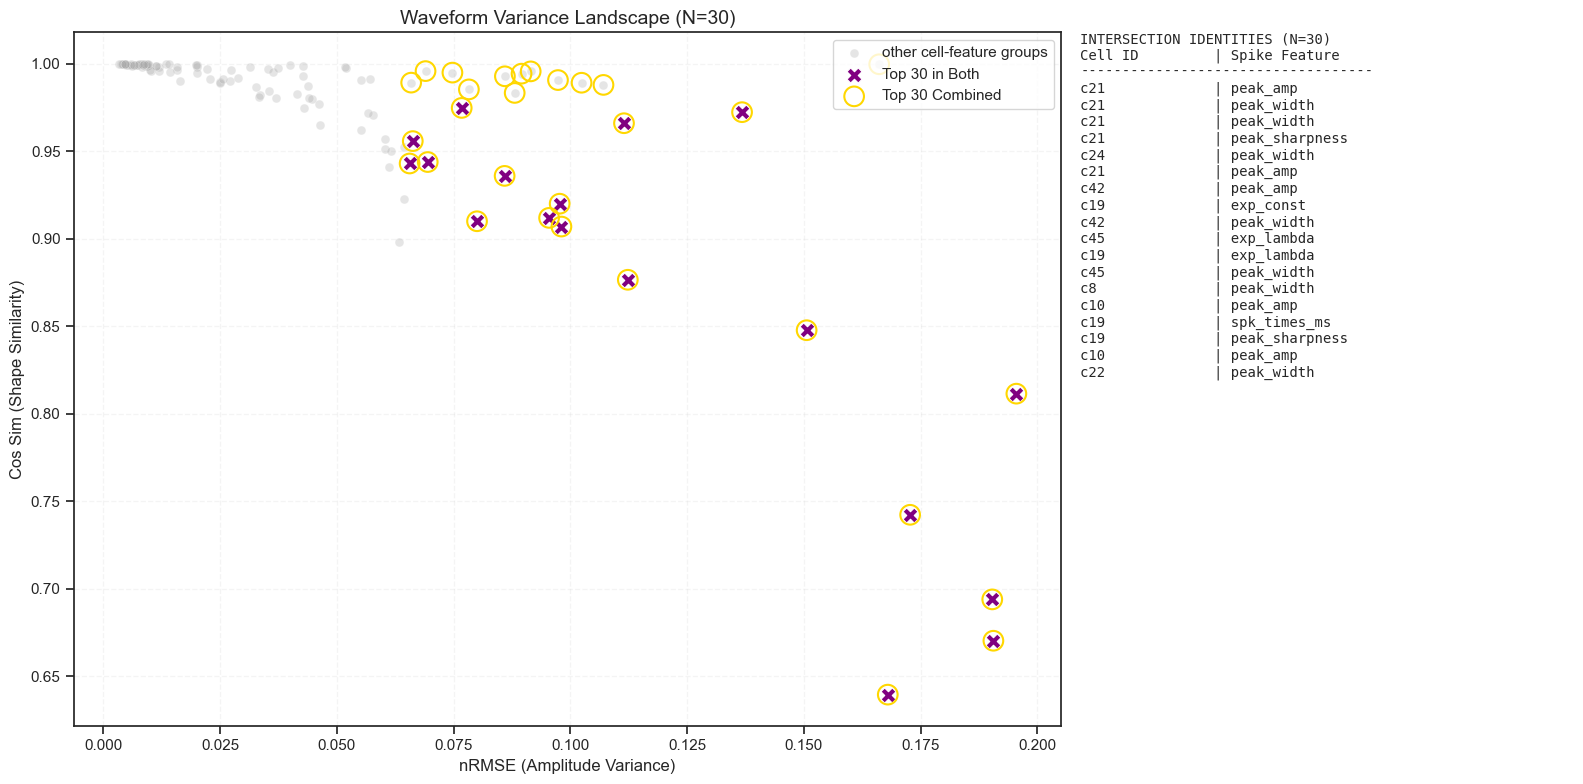

In [ ]:
top_var_df = analyze_waveform_variance(df_master, N=30)

In [ ]:
top_var_df 

,cell_id,patch_type,current_type,cell_type,cortical_depth,dark_neuron,clear_EAP_waveform,spike_feature,num_clusters,cluster,nRMSE,cos_sim,temporal_rho,temporal_p,temporal_component
62,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-High,0.195481,0.811435,-0.227997,1.471553e-115,1.0
66,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Mid-High,0.190562,0.670219,0.267964,1.651480e-160,1.0
65,c21,Juxta,IC,PC,1754.0,False,True,peak_width,3,Low-High,0.190318,0.693848,0.267964,1.651480e-160,1.0
67,c21,Juxta,IC,PC,1754.0,False,True,peak_sharpness,3,Low-High,0.172733,0.742203,-0.642336,0.000000e+00,1.0
76,c24,Juxta,VC,PC,1133.7,False,True,peak_width,3,Low-High,0.167947,0.639413,NaN,NaN,0.0
61,c21,Juxta,IC,PC,1754.0,False,True,peak_amp,3,Low-Mid,0.150572,0.847696,-0.227997,1.471553e-115,1.0
110,c42,WC,IC,PC,1348.9,False,True,peak_amp,2,Low-High,0.136746,0.972326,NaN,NaN,0.0
57,c19,Juxta,VC,PC,1180.9,False,True,exp_const,2,Low-High,0.112284,0.876527,0.145825,4.277999e-24,1.0
111,c42,WC,IC,PC,1348.9,False,True,peak_width,2,Low-High,0.111467,0.966011,NaN,NaN,0.0
123,c45,Juxta,VC,PC,1137.0,False,True,exp_lambda,3,Low-Mid,0.098067,0.906951,NaN,NaN,0.0


#### D) Temporal structure of spike clusters (drift over recording time)

**Temporal component** refers to whether a cell's spike cluster identity (i.e., which cluster a spike belongs to) systematically drifts over the course of the recording. This is measured using a Spearman correlation (ρ) between spike time and ordinal cluster label (`temporal_rho`). A significant positive ρ means spikes shift toward one cluster as time progresses; a significant negative ρ means the reverse. `temporal_component` is a binary flag (1 = statistically significant drift, p < 0.05; 0 = no significant drift).

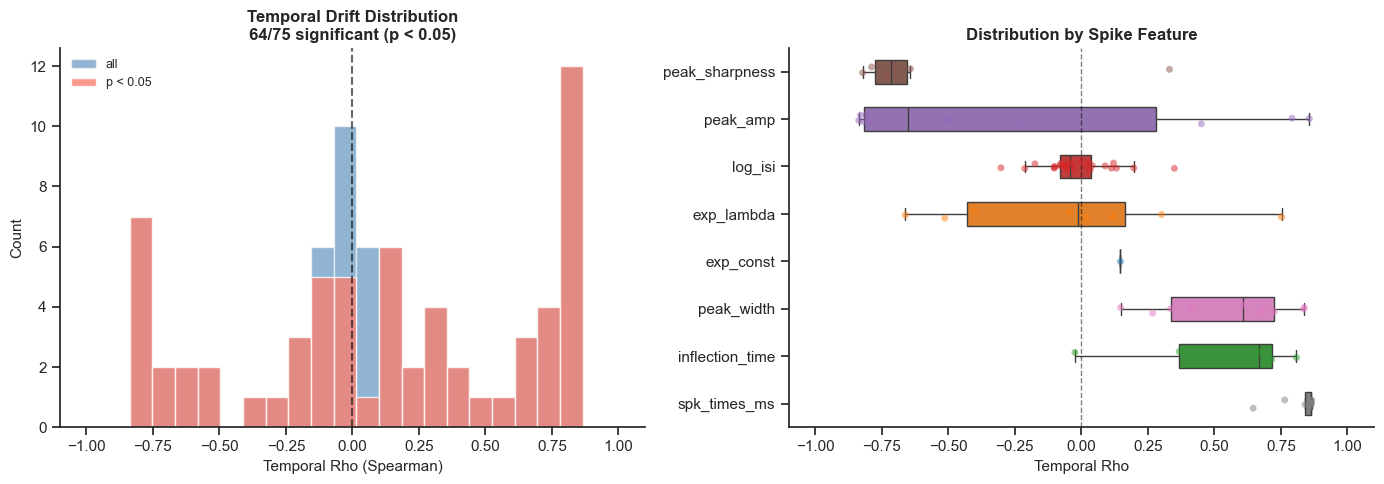


Temporal drift summary (p < 0.05):
  Significant: 64 / 75 cell-feature groups (85.3%)
  Mean |rho|: 0.419

Significant groups:
cell_id   spike_feature  temporal_rho temporal_p
     c1        peak_amp        -0.837    <0.0001
    c32        peak_amp        -0.830    <0.0001
     c7  peak_sharpness        -0.822    <0.0001
    c41        peak_amp        -0.818    <0.0001
     c3        peak_amp        -0.808    <0.0001
    c10        peak_amp        -0.799    <0.0001
    c32  peak_sharpness        -0.789    <0.0001
    c22  peak_sharpness        -0.731    <0.0001
     c1  peak_sharpness        -0.697    <0.0001
     c6      exp_lambda        -0.661    <0.0001
    c21  peak_sharpness        -0.642    <0.0001
     c1      exp_lambda        -0.513    <0.0001
    c44        peak_amp        -0.502    <0.0001
    c19      exp_lambda        -0.403    <0.0001
    c14         log_isi        -0.302    <0.0001
    c21        peak_amp        -0.228    <0.0001
    c28         log_isi        -0.213  

In [ ]:
df_temporal = plot_temporal_structure(df_master)

#### E) Does metadata predict temporal drift (temporal_rho)?

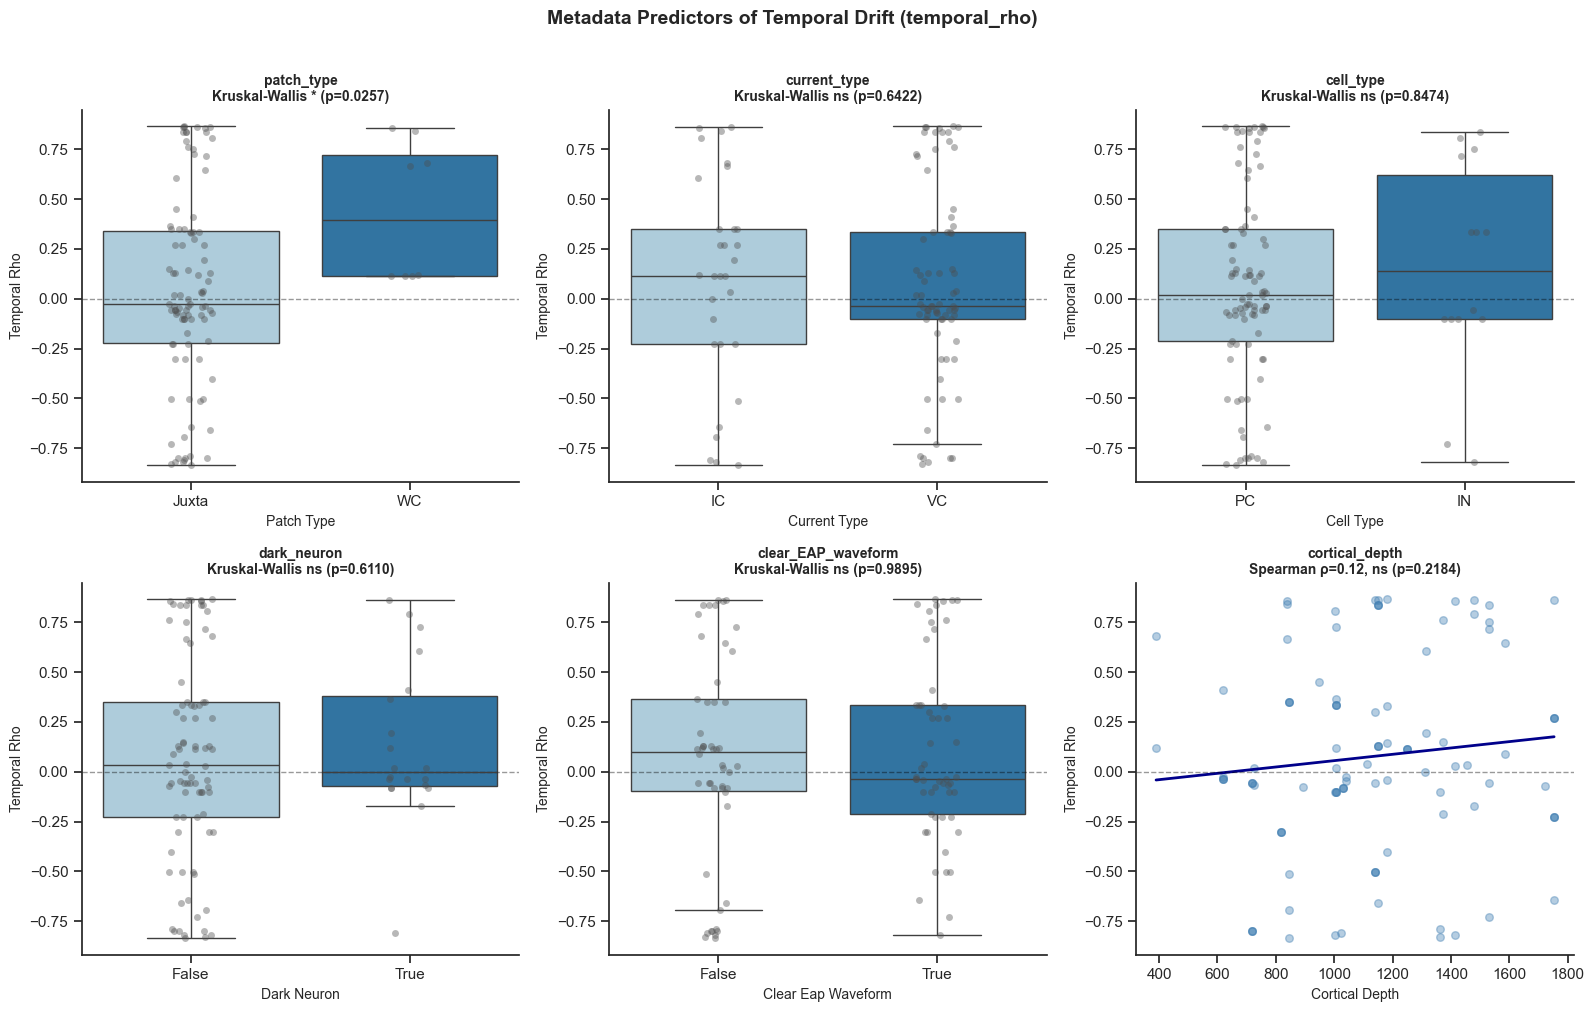


Metadata → temporal_rho test results:
          variable           test  statistic        p sig
        patch_type Kruskal-Wallis      4.975 0.025711   *
    cortical_depth       Spearman      0.122 0.218424  ns
       dark_neuron Kruskal-Wallis      0.259 0.611000  ns
      current_type Kruskal-Wallis      0.216 0.642203  ns
         cell_type Kruskal-Wallis      0.037 0.847357  ns
clear_EAP_waveform Kruskal-Wallis      0.000 0.989469  ns


,variable,test,statistic,p,sig
0,patch_type,Kruskal-Wallis,4.975,0.025711,*
1,cortical_depth,Spearman,0.122,0.218424,ns
2,dark_neuron,Kruskal-Wallis,0.259,0.611000,ns
3,current_type,Kruskal-Wallis,0.216,0.642203,ns
4,cell_type,Kruskal-Wallis,0.037,0.847357,ns
5,clear_EAP_waveform,Kruskal-Wallis,0.000,0.989469,ns


In [ ]:
temporal_meta_results = analyze_temporal_metadata_dependency(df_master)
temporal_meta_results

#### F) Is temporal drift related to clustering quality (nRMSE, cos_sim, num_clusters)?

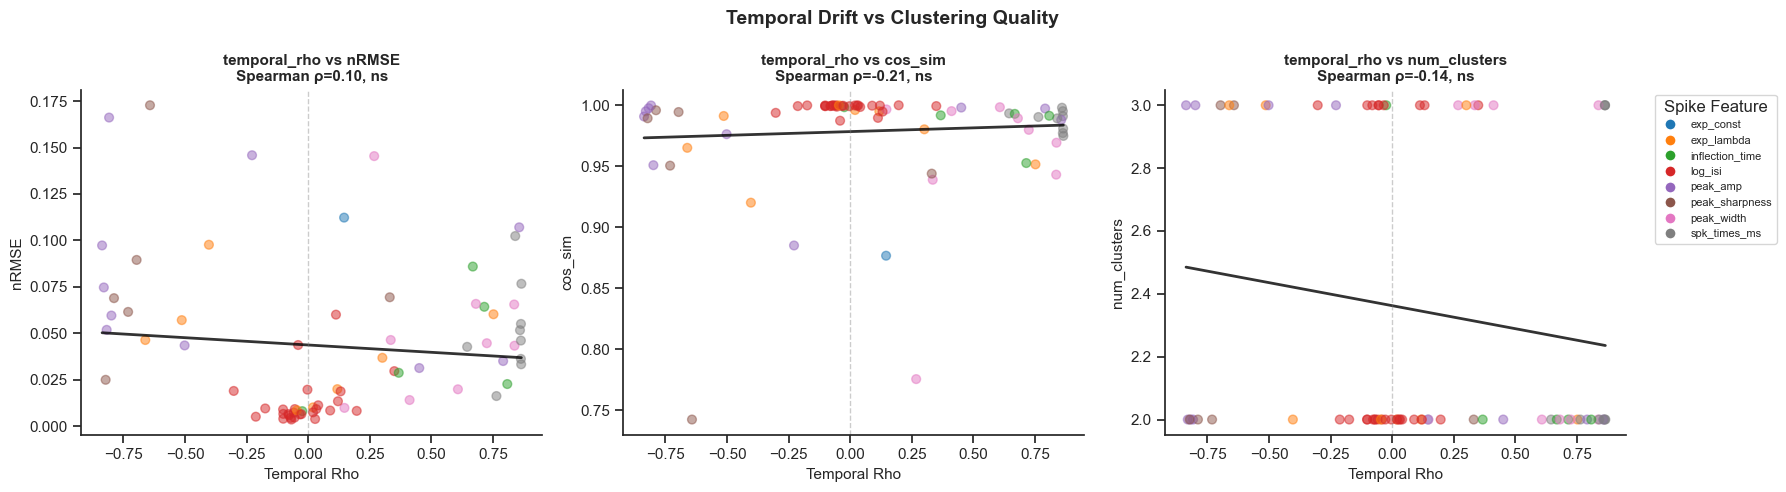

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/spk_feat_cluster_comp_analysis.py:960: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_feat.set_xticklabels(ax_feat.get_xticklabels(), rotation=30, ha='right')


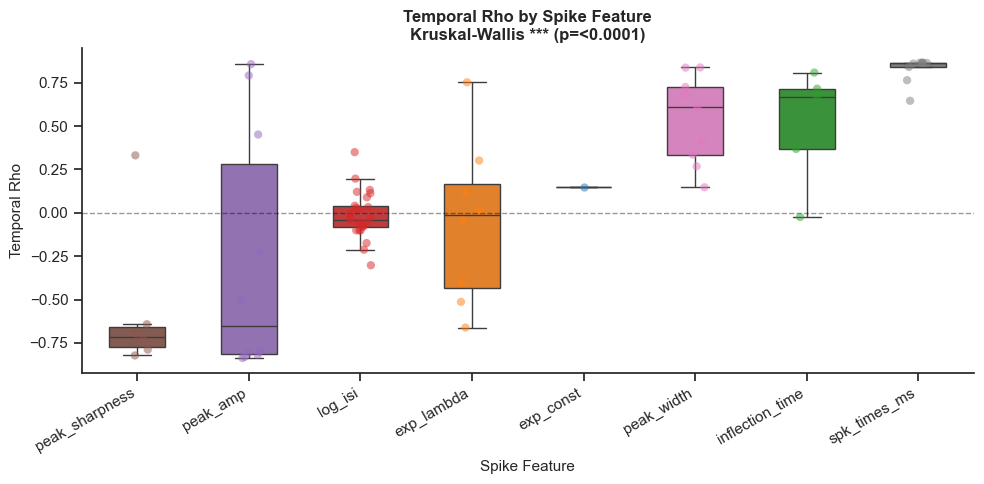

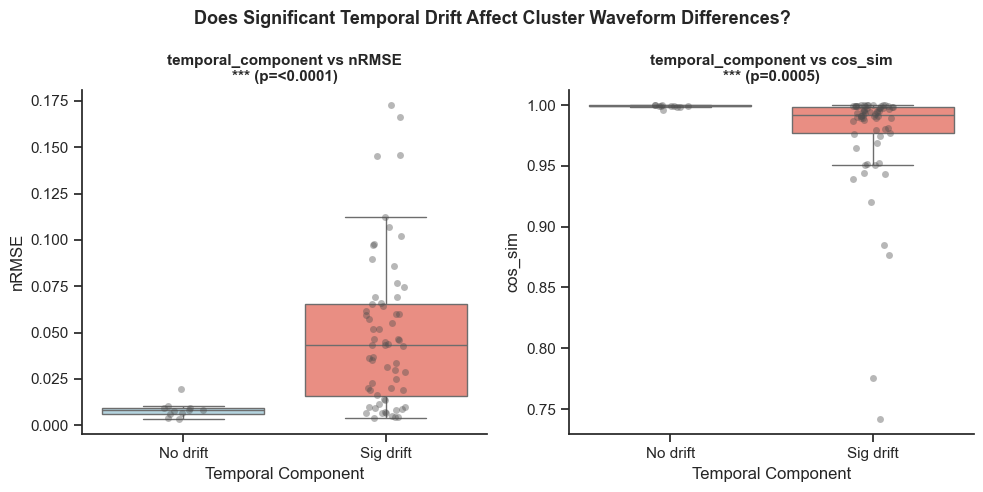


temporal_rho vs clustering metrics (Spearman):
      metric  spearman_rho        p sig
       nRMSE         0.102 0.382847  ns
     cos_sim        -0.211 0.068647  ns
num_clusters        -0.140 0.231706  ns


,metric,spearman_rho,p,sig
0,nRMSE,0.102,0.382847,ns
1,cos_sim,-0.211,0.068647,ns
2,num_clusters,-0.140,0.231706,ns


In [ ]:
temporal_clust_results = analyze_temporal_clustering_relationship(df_master)
temporal_clust_results